In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import itertools
import numpy as np
import matplotlib.pyplot as plt


Importar dataset

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

4422102/4422102 [==============================] - 0s 0us/step


Criar Conjunto de validação

In [4]:
X_train, X_validation = X_train[:-5000], X_train[-5000:]
y_train, y_validation = y_train[:-5000], y_train[-5000:]

Arquitetura da CNN

In [5]:
model = keras.models.Sequential([
    keras.layers.Conv2D(filters=32, kernel_size=3, input_shape=[28, 28, 1], activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=32,kernel_size=3, activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(filters=64,kernel_size=3, activation='relu', padding="same"),
    keras.layers.Conv2D(filters=64,kernel_size=3, activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=512, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(units=256, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax')
])

Otimizador

In [6]:
optimizer= tf.keras.optimizers.SGD(learning_rate=0.01,weight_decay=0.01)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

Treinar CNN

In [7]:
filepath = "/content/drive/MyDrive/Colab Notebooks (1)/Bandtec/Aula_11_CNN/fashion_mnist.hdf5"

In [8]:
history = model.fit(X_train, y_train, epochs=40,
                    validation_data=(X_validation, y_validation),
                    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(filepath, monitor='val_loss',
                                           verbose=1, save_best_only=True)
    ])

Epoch 1/40
1719/1719 [==============================] - ETA: 0s - loss: 0.7374 - accuracy: 0.7532
Epoch 1: val_loss improved from inf to 0.38928, saving model to /content/drive/MyDrive/Colab Notebooks (1)/Bandtec/Aula_11_CNN/fashion_mnist.hdf5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1719/1719 [==============================] - 174s 100ms/step - loss: 0.7374 - accuracy: 0.7532 - val_loss: 0.3893 - val_accuracy: 0.8558
Epoch 2/40
1719/1719 [==============================] - ETA: 0s - loss: 0.4355 - accuracy: 0.8630
Epoch 2: val_loss improved from 0.38928 to 0.32495, saving model to /content/drive/MyDrive/Colab Notebooks (1)/Bandtec/Aula_11_CNN/fashion_mnist.hdf5
1719/1719 [==============================] - 169s 98ms/step - loss: 0.4355 - accuracy: 0.8630 - val_loss: 0.3249 - val_accuracy: 0.8842
Epoch 3/40
1719/1719 [==============================] - ETA: 0s - loss: 0.3667 - accuracy: 0.8877
Epoch 3: val_loss improved from 0.32495 to 0.27737, saving model to /content/drive/MyDrive/Colab Notebooks (1)/Bandtec/Aula_11_CNN/fashion_mnist.hdf5
1719/1719 [==============================] - 170s 99ms/step - loss: 0.3667 - accuracy: 0.8877 - val_loss: 0.2774 - val_accuracy: 0.9014
Epoch 4/40
1719/1719 [==============================] - ETA: 0s - loss: 0.3289 - accuracy: 0.90

Plotar Loss e Acc

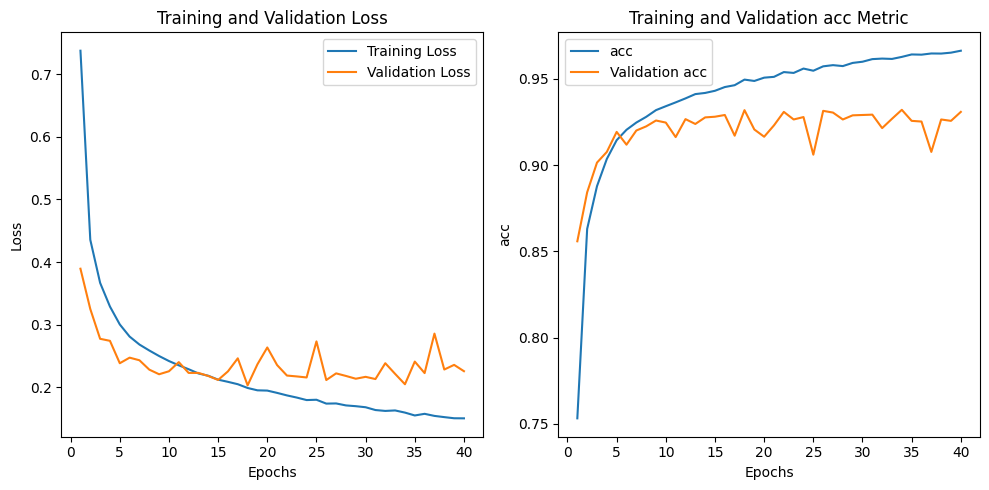

In [9]:
# Extrair métricas de treinamento e validação
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Criar gráfico
epochs = range(1, len(loss_values) + 1)

# Plot da perda
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)  # Cria uma subtrama com 1 linha e 2 colunas (gráfico da perda à esquerda)
plt.plot(epochs, loss_values, label='Training Loss')
plt.plot(epochs, val_loss_values, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot da métrica personalizada
plt.subplot(1, 2, 2)  # Cria uma subtrama com 1 linha e 2 colunas (gráfico da métrica personalizada à direita)
plt.plot(epochs, acc, label='acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and Validation acc Metric')
plt.xlabel('Epochs')
plt.ylabel('acc')
plt.legend()

plt.tight_layout()  # Garante que os gráficos não se sobreponham
plt.show()

último modelo gerado na última época

In [10]:
score = model.evaluate(X_test, y_test)
print(f'Test accuracy: {score[1]}')  # Index 1 corresponds to the accuracy metric
print(f'Test loss: {score[0]}')

313/313 [==============================] - 8s 27ms/step - loss: 0.2324 - accuracy: 0.9228
Test accuracy: 0.9228000044822693
Test loss: 0.2324429154396057


melhor modelo, com base no menor validation loss

In [11]:
melhor_modelo = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks (1)/Bandtec/Aula_11_CNN/fashion_mnist.hdf5")

melhor_score = melhor_modelo.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {melhor_score[1]}')  # Index 1 corresponds to the accuracy metric
print(f'Test loss: {melhor_score[0]}')


Test accuracy: 0.9273999929428101
Test loss: 0.22141775488853455


Usar a base de testes e verificar acc e loss no melhor modelo

In [12]:
y_pred = melhor_modelo.predict(X_test)

313/313 [==============================] - 7s 24ms/step


Previsão de classe para a posição 16 do dataset de teste = Logits (dificil de entender)

In [13]:
y_pred[16]

array([0.01002863, 0.00208149, 0.9245354 , 0.00214387, 0.00738238,
       0.00240423, 0.04620632, 0.00113215, 0.00164877, 0.00243674],
      dtype=float32)

Previsão de classe para a posição 16 do dataset de teste =  (maior logit)

In [14]:
np.argmax(y_pred[16])

2

In [15]:
y_test[16]

2

Converter Logit para probabilidade (fácil de entender)

In [16]:
100*np.max(y_pred[16])

92.45353937149048

Você pode criar um código para percorrer todas as posições dos vetores y_test e y_pred e verificar se a confiança (probabilidade máxima) é maior que certo threshold. Em seguida, você pode calcular a precisão (accuracy) do modelo para os casos em que a confiança é maior que a porcentagem escolhida. Aqui está um exemplo de código para fazer isso:

In [17]:
# Assuming you have y_test, y_pred, and confidences
# y_test contém o valor real das classes
# y_pred contém o valor predito
# confidences contém as confianças calculadas

# Initialize lists to store indices of confident predictions and their corresponding true labels and predicted labels
confident_indices = []
confident_true_labels = []
confident_predicted_labels = []

# Set the confidence threshold (e.g., 70%)
confidence_threshold = 70

# Iterate through predictions and confidences
for i in range(len(y_test)):
    confidence = 100 * np.max(y_pred[i])
    if confidence > confidence_threshold:
        confident_indices.append(i)
        confident_true_labels.append(y_test[i])
        confident_predicted_labels.append(np.argmax(y_pred[i]))
    #else:
       # print(i, y_test[i], np.argmax(y_pred[i]), confidence)

# Calculate accuracy for confident predictions
accuracy = accuracy_score(confident_true_labels, confident_predicted_labels)

# Print the accuracy for confident predictions
print(f"Accuracy para os Predictions onde (Confidence > {confidence_threshold}%): {accuracy:.2f}")


Accuracy para os Predictions onde (Confidence > 70%): 0.96


In [22]:
def plot_confusion_matrix(cm, class_, title='Confusion matrix', cmap=plt.cm.Reds):
    """
    This function plots a confusion matrix
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    tick_marks = np.arange(len(class_))
    plt.xticks(tick_marks, class_, rotation=90)
    plt.yticks(tick_marks, class_)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True labels')
    plt.xlabel('Predicted labels')
    plt.show()

In [47]:
# Mapear os rótulos de classe de números inteiros para nomes de classe legíveis
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
y_pred_new = []

for i in range(len(y_pred)):
    y_pred_new.append(np.argmax(y_pred[i]))

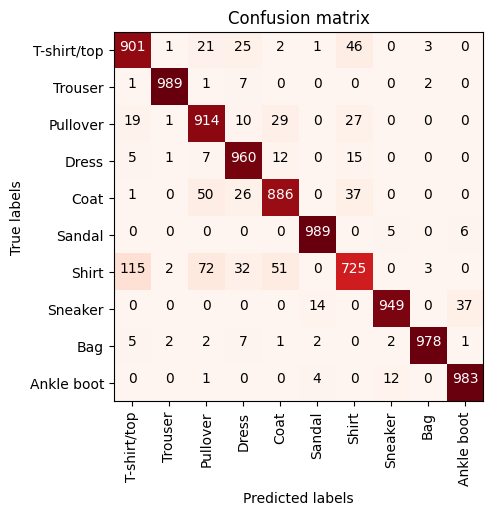

In [48]:
plot_confusion_matrix(confusion_matrix(y_test, y_pred_new), list(class_names))

In [50]:
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1000
           1       0.99      0.99      0.99      1000
           2       0.86      0.91      0.88      1000
           3       0.90      0.96      0.93      1000
           4       0.90      0.89      0.89      1000
           5       0.98      0.99      0.98      1000
           6       0.85      0.72      0.78      1000
           7       0.98      0.95      0.96      1000
           8       0.99      0.98      0.98      1000
           9       0.96      0.98      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

